In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Load the Datasets

In [2]:
tasks = pd.read_csv("../data/processed/tasks_processed.csv")
employees = pd.read_csv("../data/processed/employees_processed.csv")
workload = pd.read_csv("../data/processed/workload_processed.csv")

Verify the Data

In [3]:
print("Tasks Shape:", tasks.shape)
print("Employees Shape:", employees.shape)
print("Workload Shape:", workload.shape)

Tasks Shape: (10000, 20)
Employees Shape: (500, 12)
Workload Shape: (500, 11)


Preview the Data

In [4]:
tasks.head()

,Task_ID,Task_Title,Task_Description,Category,Priority,Status,Project_Name,Module,Sprint,Story_Points,Created_Date,Due_Date,Estimated_Hours,Actual_Hours,Assigned_To,Environment,Severity,Labels,SLA_Hours,Completion_Status
0,TASK-10001,Support: Investigate Payments,House answer start behind old travel Democrat ...,Support,Medium,Review,Apollo,Security,Sprint 7,1,2025-03-02,2025-03-08,2,1,EMP020,Development,Minor,support,96,Yes
1,TASK-10002,Documentation: Implement UI,Way officer however wish another teach face ce...,Documentation,Medium,Open,Vertex,Authentication,Sprint 8,1,2025-10-12,2025-10-16,2,1,EMP024,Production,Minor,documentation,48,No
2,TASK-10003,Enhancement: Fix UI,Recognize each off modern themselves role expl...,Enhancement,Low,Completed,Nova,Reporting,Sprint 4,3,2025-02-13,2025-03-04,6,6,EMP281,Production,Minor,enhancement,24,Yes
3,TASK-10004,UI/UX: Improve Notifications,Of then finish receive organization oil lay st...,UI/UX,Medium,Completed,Titan,Reporting,Sprint 10,8,2025-11-09,2025-11-17,16,20,EMP128,Development,Minor,ui-ux,48,No
4,TASK-10005,Testing: Improve UI,Can easy hospital the ball last near third sta...,Testing,Medium,Open,Phoenix,Security,Sprint 14,3,2024-08-21,2024-09-08,6,11,EMP085,UAT,Minor,testing,48,Yes


In [5]:
employees.head()

,Employee_ID,Employee_Name,Email,Department,Designation,Experience_Years,Primary_Skills,Performance_Score,Current_Workload,Availability,Location,Joining_Year
0,EMP001,Pushti Subramanian,emp1@company.com,Support,Associate,10,"ITIL, Windows, ServiceNow",3.41,7,Busy,Hyderabad,2015
1,EMP002,Samuel Shere,emp2@company.com,Database,Senior Engineer,4,"MongoDB, Oracle, SQL Server",3.09,2,On Leave,Chennai,2021
2,EMP003,Arunima Dyal,emp3@company.com,Cloud,Senior Engineer,3,"GCP, Networking, AWS",4.32,2,Busy,Hyderabad,2022
3,EMP004,Vrishti Narang,emp4@company.com,Support,Engineer,1,"Windows, ITIL, Troubleshooting",3.27,4,On Leave,Chennai,2018
4,EMP005,Zaid Patel,emp5@company.com,AI/ML,Associate,8,"ML, NLP, TensorFlow",4.31,5,On Leave,Hyderabad,2018


In [6]:
workload.head()

,Employee_ID,Department,Active_Tasks,Completed_This_Month,Pending_Tasks,Average_Task_Hours,Available_Hours_Per_Week,Max_Task_Capacity,Utilization_Percentage,Availability_Status,Last_Updated
0,EMP001,Database,7,26,5,3.4,20,12,58.3,Partially Available,2026-07-10
1,EMP002,Security,7,27,9,4.3,20,12,58.3,Busy,2026-07-10
2,EMP003,QA,7,15,3,2.6,25,12,58.3,Available,2026-07-10
3,EMP004,Cloud,8,30,1,2.2,20,12,66.7,Busy,2026-07-10
4,EMP005,Security,1,8,10,6.2,25,15,6.7,Partially Available,2026-07-10


Check Dataset Information

In [7]:
tasks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Task_ID            10000 non-null  object
 1   Task_Title         10000 non-null  object
 2   Task_Description   10000 non-null  object
 3   Category           10000 non-null  object
 4   Priority           10000 non-null  object
 5   Status             10000 non-null  object
 6   Project_Name       10000 non-null  object
 7   Module             10000 non-null  object
 8   Sprint             10000 non-null  object
 9   Story_Points       10000 non-null  int64 
 10  Created_Date       10000 non-null  object
 11  Due_Date           10000 non-null  object
 12  Estimated_Hours    10000 non-null  int64 
 13  Actual_Hours       10000 non-null  int64 
 14  Assigned_To        10000 non-null  object
 15  Environment        10000 non-null  object
 16  Severity           10000 non-null  object

In [8]:
employees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        500 non-null    object 
 1   Employee_Name      500 non-null    object 
 2   Email              500 non-null    object 
 3   Department         500 non-null    object 
 4   Designation        500 non-null    object 
 5   Experience_Years   500 non-null    int64  
 6   Primary_Skills     500 non-null    object 
 7   Performance_Score  500 non-null    float64
 8   Current_Workload   500 non-null    int64  
 9   Availability       500 non-null    object 
 10  Location           500 non-null    object 
 11  Joining_Year       500 non-null    int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 47.0+ KB


In [9]:
workload.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Employee_ID               500 non-null    object 
 1   Department                500 non-null    object 
 2   Active_Tasks              500 non-null    int64  
 3   Completed_This_Month      500 non-null    int64  
 4   Pending_Tasks             500 non-null    int64  
 5   Average_Task_Hours        500 non-null    float64
 6   Available_Hours_Per_Week  500 non-null    int64  
 7   Max_Task_Capacity         500 non-null    int64  
 8   Utilization_Percentage    500 non-null    float64
 9   Availability_Status       500 non-null    object 
 10  Last_Updated              500 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 43.1+ KB


Check Missing Values

In [10]:
print(tasks.isnull().sum())
print(employees.isnull().sum())
print(workload.isnull().sum())

Task_ID              0
Task_Title           0
Task_Description     0
Category             0
Priority             0
Status               0
Project_Name         0
Module               0
Sprint               0
Story_Points         0
Created_Date         0
Due_Date             0
Estimated_Hours      0
Actual_Hours         0
Assigned_To          0
Environment          0
Severity             0
Labels               0
SLA_Hours            0
Completion_Status    0
dtype: int64
Employee_ID          0
Employee_Name        0
Email                0
Department           0
Designation          0
Experience_Years     0
Primary_Skills       0
Performance_Score    0
Current_Workload     0
Availability         0
Location             0
Joining_Year         0
dtype: int64
Employee_ID                 0
Department                  0
Active_Tasks                0
Completed_This_Month        0
Pending_Tasks               0
Average_Task_Hours          0
Available_Hours_Per_Week    0
Max_Task_Capacity           

Check Column Names

In [11]:
print(tasks.columns.tolist())
print(employees.columns.tolist())
print(workload.columns.tolist())

['Task_ID', 'Task_Title', 'Task_Description', 'Category', 'Priority', 'Status', 'Project_Name', 'Module', 'Sprint', 'Story_Points', 'Created_Date', 'Due_Date', 'Estimated_Hours', 'Actual_Hours', 'Assigned_To', 'Environment', 'Severity', 'Labels', 'SLA_Hours', 'Completion_Status']
['Employee_ID', 'Employee_Name', 'Email', 'Department', 'Designation', 'Experience_Years', 'Primary_Skills', 'Performance_Score', 'Current_Workload', 'Availability', 'Location', 'Joining_Year']
['Employee_ID', 'Department', 'Active_Tasks', 'Completed_This_Month', 'Pending_Tasks', 'Average_Task_Hours', 'Available_Hours_Per_Week', 'Max_Task_Capacity', 'Utilization_Percentage', 'Availability_Status', 'Last_Updated']


Merge Employee and Workload Data

In [12]:
employee_workload = employees.merge(
    workload,
    on="Employee_ID",
    how="left"
)

employee_workload.head()

,Employee_ID,Employee_Name,Email,Department_x,Designation,Experience_Years,Primary_Skills,Performance_Score,Current_Workload,Availability,...,Department_y,Active_Tasks,Completed_This_Month,Pending_Tasks,Average_Task_Hours,Available_Hours_Per_Week,Max_Task_Capacity,Utilization_Percentage,Availability_Status,Last_Updated
0,EMP001,Pushti Subramanian,emp1@company.com,Support,Associate,10,"ITIL, Windows, ServiceNow",3.41,7,Busy,...,Database,7,26,5,3.4,20,12,58.3,Partially Available,2026-07-10
1,EMP002,Samuel Shere,emp2@company.com,Database,Senior Engineer,4,"MongoDB, Oracle, SQL Server",3.09,2,On Leave,...,Security,7,27,9,4.3,20,12,58.3,Busy,2026-07-10
2,EMP003,Arunima Dyal,emp3@company.com,Cloud,Senior Engineer,3,"GCP, Networking, AWS",4.32,2,Busy,...,QA,7,15,3,2.6,25,12,58.3,Available,2026-07-10
3,EMP004,Vrishti Narang,emp4@company.com,Support,Engineer,1,"Windows, ITIL, Troubleshooting",3.27,4,On Leave,...,Cloud,8,30,1,2.2,20,12,66.7,Busy,2026-07-10
4,EMP005,Zaid Patel,emp5@company.com,AI/ML,Associate,8,"ML, NLP, TensorFlow",4.31,5,On Leave,...,Security,1,8,10,6.2,25,15,6.7,Partially Available,2026-07-10


Verify the Merge

In [13]:
print(employee_workload.shape)
employee_workload.info()

(500, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Employee_ID               500 non-null    object 
 1   Employee_Name             500 non-null    object 
 2   Email                     500 non-null    object 
 3   Department_x              500 non-null    object 
 4   Designation               500 non-null    object 
 5   Experience_Years          500 non-null    int64  
 6   Primary_Skills            500 non-null    object 
 7   Performance_Score         500 non-null    float64
 8   Current_Workload          500 non-null    int64  
 9   Availability              500 non-null    object 
 10  Location                  500 non-null    object 
 11  Joining_Year              500 non-null    int64  
 12  Department_y              500 non-null    object 
 13  Active_Tasks              500 non-null    int64  
 14  

Check Current Workload Distribution

In [17]:
employee_workload.columns.tolist()

['Employee_ID',
 'Employee_Name',
 'Email',
 'Department_x',
 'Designation',
 'Experience_Years',
 'Primary_Skills',
 'Performance_Score',
 'Current_Workload',
 'Availability',
 'Location',
 'Joining_Year',
 'Department_y',
 'Active_Tasks',
 'Completed_This_Month',
 'Pending_Tasks',
 'Average_Task_Hours',
 'Available_Hours_Per_Week',
 'Max_Task_Capacity',
 'Utilization_Percentage',
 'Availability_Status',
 'Last_Updated']

In [18]:
employee_workload.rename(
    columns={
        "Department_x": "Department",
        "Department_y": "Workload_Department"
    },
    inplace=True
)

In [19]:
employee_workload.columns.tolist()

['Employee_ID',
 'Employee_Name',
 'Email',
 'Department',
 'Designation',
 'Experience_Years',
 'Primary_Skills',
 'Performance_Score',
 'Current_Workload',
 'Availability',
 'Location',
 'Joining_Year',
 'Workload_Department',
 'Active_Tasks',
 'Completed_This_Month',
 'Pending_Tasks',
 'Average_Task_Hours',
 'Available_Hours_Per_Week',
 'Max_Task_Capacity',
 'Utilization_Percentage',
 'Availability_Status',
 'Last_Updated']

In [20]:
employee_workload[
    [
        "Employee_Name",
        "Department",
        "Current_Workload",
        "Active_Tasks",
        "Pending_Tasks",
        "Utilization_Percentage"
    ]
].head()

,Employee_Name,Department,Current_Workload,Active_Tasks,Pending_Tasks,Utilization_Percentage
0,Pushti Subramanian,Support,7,7,5,58.3
1,Samuel Shere,Database,2,7,9,58.3
2,Arunima Dyal,Cloud,2,7,3,58.3
3,Vrishti Narang,Support,4,8,1,66.7
4,Zaid Patel,AI/ML,5,1,10,6.7


Top 10 Busy Employees

In [21]:
top_busy = employee_workload.sort_values(
    by="Utilization_Percentage",
    ascending=False
)

top_busy[
    [
        "Employee_Name",
        "Department",
        "Utilization_Percentage",
        "Active_Tasks",
        "Pending_Tasks"
    ]
].head(10)

,Employee_Name,Department,Utilization_Percentage,Active_Tasks,Pending_Tasks
284,Lajita Khanna,Cloud,150.0,12,5
354,Anmol Kalla,QA,150.0,12,6
256,Isha Boase,Security,150.0,12,4
416,Abha Dixit,Backend,150.0,12,7
72,Amol Narang,QA,150.0,12,0
78,Amol Ramanathan,Support,150.0,12,5
87,Urishilla Seth,Database,150.0,12,5
392,Zilmil Bhatt,Database,137.5,11,10
40,Aarnav Sarna,QA,137.5,11,0
305,Libni Kumar,Database,137.5,11,9


Top 10 Least Busy Employees

In [22]:
least_busy = employee_workload.sort_values(
    by="Utilization_Percentage"
)

least_busy[
    [
        "Employee_Name",
        "Department",
        "Utilization_Percentage",
        "Active_Tasks",
        "Pending_Tasks"
    ]
].head(10)

,Employee_Name,Department,Utilization_Percentage,Active_Tasks,Pending_Tasks
393,Hema Rao,Backend,0.0,0,4
414,Luke Baria,AI/ML,0.0,0,3
250,Amara Dutta,QA,0.0,0,0
141,Avi Prasad,Frontend,0.0,0,0
403,Aarnav Thakkar,Frontend,0.0,0,10
178,Abhimanyu Venkatesh,Security,0.0,0,10
379,Kashish Gala,Security,0.0,0,10
241,Dayita Patel,Backend,0.0,0,3
179,Vasudha Chada,Security,0.0,0,10
239,Zinal Barman,QA,0.0,0,9


Histogram

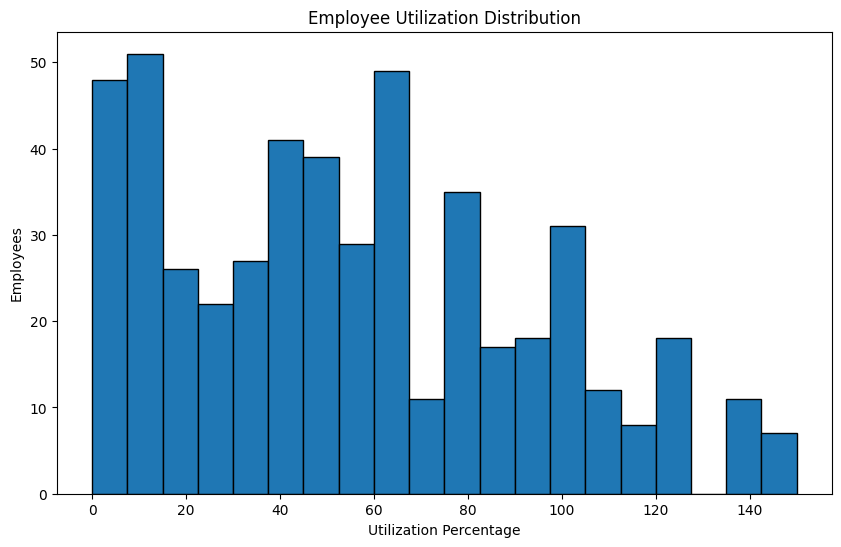

In [23]:
plt.figure(figsize=(10,6))

plt.hist(
    employee_workload["Utilization_Percentage"],
    bins=20,
    edgecolor="black"
)

plt.title("Employee Utilization Distribution")
plt.xlabel("Utilization Percentage")
plt.ylabel("Employees")

plt.show()

Categorize Employees

In [24]:
def workload_status(util):

    if util < 50:
        return "Underloaded"

    elif util <= 80:
        return "Balanced"

    else:
        return "Overloaded"


employee_workload["Workload_Status"] = employee_workload[
    "Utilization_Percentage"
].apply(workload_status)

Distribution

In [25]:
employee_workload["Workload_Status"].value_counts()

Workload_Status
Underloaded    221
Balanced       157
Overloaded     122
Name: count, dtype: int64

Bar Chart

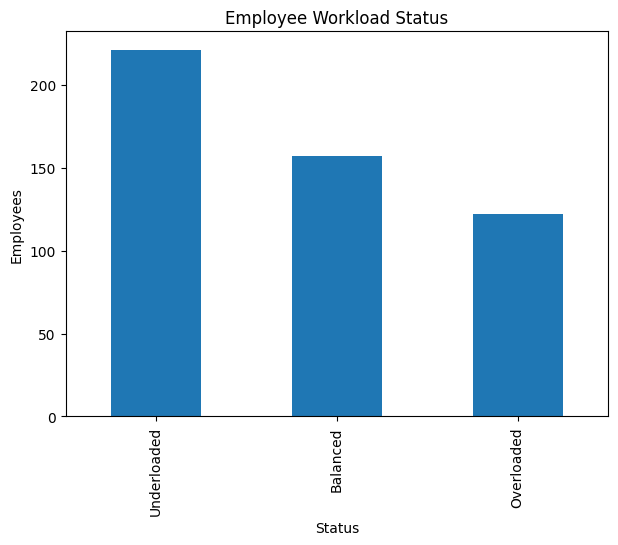

In [26]:
employee_workload["Workload_Status"].value_counts().plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Employee Workload Status")
plt.xlabel("Status")
plt.ylabel("Employees")

plt.show()